<a href="https://colab.research.google.com/github/mohit12kumar/project-3/blob/main/cancellation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRARY IMPORTS AND DATASET LOADER

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gc
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
filepath = r'https://media.githubusercontent.com/media/mohit12kumar/dataset4/refs/heads/main/project14.csv'
data = pd.read_csv(filepath)
data.head()

,AIRLINE,ORIGIN,DEST,DEP_DELAY,DISTANCE,CRS_DEP_TIME,month,day_of_week,is_weekend,ARR_DELAY,CANCELLED
0,17,131,123,-4.0,1065.0,1155,1,3,0,-14.0,0.0
1,3,247,323,-6.0,1399.0,2120,1,3,0,-5.0,0.0
2,17,99,247,6.0,680.0,954,1,3,0,0.0,0.0
3,3,247,325,-1.0,1589.0,1609,1,3,0,24.0,0.0
4,16,223,100,-2.0,985.0,1840,1,3,0,-1.0,0.0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 11 columns):
 #   Column        Dtype  
---  ------        -----  
 0   AIRLINE       int64  
 1   ORIGIN        int64  
 2   DEST          int64  
 3   DEP_DELAY     float64
 4   DISTANCE      float64
 5   CRS_DEP_TIME  int64  
 6   month         int64  
 7   day_of_week   int64  
 8   is_weekend    int64  
 9   ARR_DELAY     float64
 10  CANCELLED     float64
dtypes: float64(4), int64(7)
memory usage: 251.8 MB


In [3]:
data[data['CANCELLED'] == 1]

,AIRLINE,ORIGIN,DEST,DEP_DELAY,DISTANCE,CRS_DEP_TIME,month,day_of_week,is_weekend,ARR_DELAY,CANCELLED
14,15,332,201,0.0,308.0,2155,1,3,0,0.0,1.0
45,13,261,96,0.0,612.0,1935,1,3,0,0.0,1.0
80,15,47,23,0.0,214.0,1055,1,3,0,0.0,1.0
191,0,172,201,0.0,2288.0,1720,1,3,0,0.0,1.0
236,15,199,164,0.0,1235.0,500,1,3,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2999779,12,96,64,0.0,274.0,1959,1,3,0,0.0,1.0
2999865,14,261,228,0.0,491.0,1530,1,3,0,0.0,1.0
2999910,1,272,344,0.0,1447.0,1504,1,3,0,0.0,1.0
2999943,2,131,77,0.0,632.0,1443,1,3,0,0.0,1.0


In [4]:
from sklearn.utils import resample

df_major = data[data['CANCELLED'] == 0]   # False
df_minor = data[data['CANCELLED'] == 1]   # True
df_major_downsampled = resample(
    df_major,
    replace=False,                 # no duplication
    n_samples=len(df_minor),       # match minority
    random_state=42
)

# Combine
df_balanced = pd.concat([df_major_downsampled, df_minor])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)

DECLARING X AND Y FOR MODELS

In [5]:


x1 = df_balanced[[
    'AIRLINE',
    'ORIGIN',
    'DEST',
    'DEP_DELAY',
    'DISTANCE',
    'CRS_DEP_TIME',
    'month',
    'day_of_week',
    'is_weekend'
]]

y1 = df_balanced['CANCELLED']

x1_train,x1_test,y1_train,y1_test = train_test_split(x1,y1,test_size = 0.2 , random_state = 42 )

RANDOMFORESTCLASSIFIER MODEL

Best Threshold: 0.3500000000000001
Best F1 Score: 0.9679080459770115

 test accuracy =  0.9592178417993429
Report:
               precision    recall  f1-score   support

         0.0       0.96      0.95      0.96     15589
         1.0       0.96      0.96      0.96     16067

    accuracy                           0.96     31656
   macro avg       0.96      0.96      0.96     31656
weighted avg       0.96      0.96      0.96     31656

confusion matrix:
 [[14865   724]
 [  567 15500]]


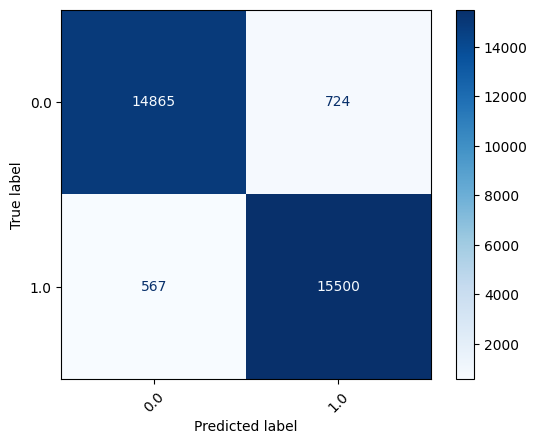

45

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=2,
    random_state=42
)
rf.fit(x1_train, y1_train)
y_prob = rf.predict_proba(x1_test)[:,1]

# threshold = 0.20
# rf_pred = (y_prob > threshold).astype(int)
from sklearn.metrics import f1_score

best_thresh = 0
best_score = 0

for t in np.arange(0.1, 0.9, 0.05):
    rf_pred = (y_prob > t).astype(int)
    score = f1_score(y1_test, rf_pred)

    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1 Score:", best_score)

print("\n test accuracy = ",accuracy_score(y1_test,rf_pred))
print("Report:\n", classification_report(y1_test, rf_pred))
c1 = confusion_matrix(y1_test,rf_pred)
print("confusion matrix:\n",c1)
unique_labels = sorted(list(set(y1_test).union(set(rf_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c1,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()


LOGISTIC REGRESSION MODEL

[1 0 1 ... 1 1 1] 617363     1.0
1154800    1.0
2410028    0.0
1152406    0.0
1549074    0.0
          ... 
2424465    1.0
369652     0.0
83906      0.0
2748844    1.0
1941544    1.0
Name: CANCELLED, Length: 31656, dtype: float64

 test accuracy =  0.5308946171341926
Report:
               precision    recall  f1-score   support

         0.0       0.56      0.22      0.31     15589
         1.0       0.52      0.84      0.64     16067

    accuracy                           0.53     31656
   macro avg       0.54      0.53      0.48     31656
weighted avg       0.54      0.53      0.48     31656

confusion matrix:
 [[ 3375 12214]
 [ 2636 13431]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


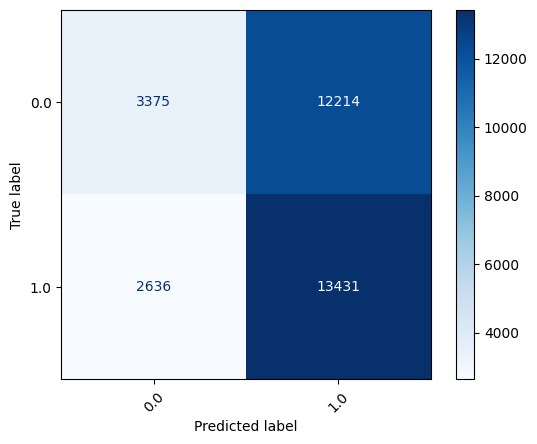

4544

In [7]:
scaler = StandardScaler()

x1_trains = scaler.fit_transform(x1_train)
x1_tests = scaler.transform(x1_test)


lr=LogisticRegression(class_weight='balanced',max_iter=500,
    n_jobs=-1)
lr.fit(x1_trains, y1_train)
y_prob = lr.predict_proba(x1_test)[:,1]

threshold = 0.35
lr_pred = (y_prob > threshold).astype(int)
print(lr_pred,y1_test)

print("\n test accuracy = ",accuracy_score(y1_test,lr_pred))
print("Report:\n", classification_report(y1_test, lr_pred))
c2 = confusion_matrix(y1_test,lr_pred)
print("confusion matrix:\n",c2)
unique_labels = sorted(list(set(y1_test).union(set(lr_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c2,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

In [8]:
print("Scaler mean:", scaler.mean_)
print("Scaler scale:", scaler.scale_)

Scaler mean: [9.68012383e+00 1.83939617e+02 1.83502614e+02 5.66001706e+00
 7.76281440e+02 1.34531311e+03 1.00000000e+00 3.00000000e+00
 0.00000000e+00]
Scaler scale: [  5.80584547 100.73546093 100.67710465  38.46195572 554.86718019
 492.25219849   1.           1.           1.        ]


DECISION TREE MODEL

[1 1 0 ... 0 1 1] 617363     1.0
1154800    1.0
2410028    0.0
1152406    0.0
1549074    0.0
          ... 
2424465    1.0
369652     0.0
83906      0.0
2748844    1.0
1941544    1.0
Name: CANCELLED, Length: 31656, dtype: float64

 test accuracy =  0.9362838008592368
Report:
               precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     15589
         1.0       0.93      0.94      0.94     16067

    accuracy                           0.94     31656
   macro avg       0.94      0.94      0.94     31656
weighted avg       0.94      0.94      0.94     31656

confusion matrix:
 [[14537  1052]
 [  965 15102]]


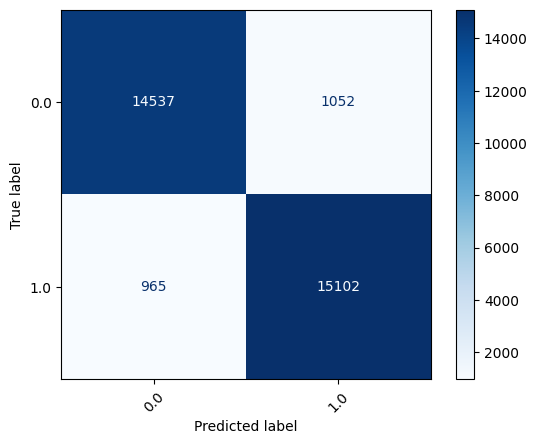

4275

In [9]:
dt=DecisionTreeClassifier(class_weight='balanced')
dt.fit(x1_train, y1_train)
y_prob = dt.predict_proba(x1_test)[:,1]

threshold = 0.35
dt_pred = (y_prob > threshold).astype(int)
print(dt_pred,y1_test)

print("\n test accuracy = ",accuracy_score(y1_test,dt_pred))
print("Report:\n", classification_report(y1_test, dt_pred))
c3 = confusion_matrix(y1_test,dt_pred)
print("confusion matrix:\n",c3)
unique_labels = sorted(list(set(y1_test).union(set(dt_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c3,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

K-NEIGHBORS CLASSIFIER

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


[1 1 0 ... 1 0 1] 617363     1.0
1154800    1.0
2410028    0.0
1152406    0.0
1549074    0.0
          ... 
2424465    1.0
369652     0.0
83906      0.0
2748844    1.0
1941544    1.0
Name: CANCELLED, Length: 31656, dtype: float64

 test accuracy =  0.497093757897397
Report:
               precision    recall  f1-score   support

         0.0       0.48      0.33      0.39     15589
         1.0       0.50      0.66      0.57     16067

    accuracy                           0.50     31656
   macro avg       0.49      0.49      0.48     31656
weighted avg       0.49      0.50      0.48     31656

confusion matrix:
 [[ 5106 10483]
 [ 5437 10630]]


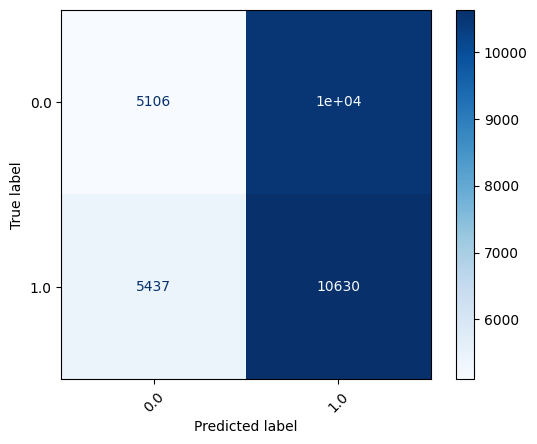

4481

In [10]:
scaler = StandardScaler()

x1_trains = scaler.fit_transform(x1_train)
x1_tests = scaler.transform(x1_test)

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x1_trains, y1_train)
y_prob = knn.predict_proba(x1_test)[:,1]

threshold = 0.35
knn_pred = (y_prob > threshold).astype(int)
print(knn_pred,y1_test)

print("\n test accuracy = ",accuracy_score(y1_test,knn_pred))
print("Report:\n", classification_report(y1_test, knn_pred))
c4 = confusion_matrix(y1_test,knn_pred)
print("confusion matrix:\n",c4)
unique_labels = sorted(list(set(y1_test).union(set(knn_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c4,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

TYPE OF SVM MODEL LINEAR SVC

[1 0 1 ... 0 1 1] 617363     1.0
1154800    1.0
2410028    0.0
1152406    0.0
1549074    0.0
          ... 
2424465    1.0
369652     0.0
83906      0.0
2748844    1.0
1941544    1.0
Name: CANCELLED, Length: 31656, dtype: float64

 test accuracy =  0.5300732878443265
Report:
               precision    recall  f1-score   support

         0.0       0.55      0.25      0.34     15589
         1.0       0.52      0.80      0.63     16067

    accuracy                           0.53     31656
   macro avg       0.54      0.53      0.49     31656
weighted avg       0.54      0.53      0.49     31656

confusion matrix:
 [[ 3852 11737]
 [ 3139 12928]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearSVC was fitted without feature names
  warnings.warn(


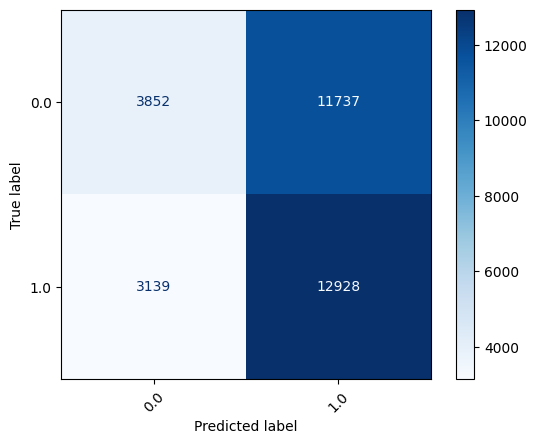

4266

In [11]:
from sklearn.linear_model import SGDClassifier
scaler = StandardScaler()
x1_trains = scaler.fit_transform(x1_train)
x1_tests = scaler.transform(x1_test)
svm = LinearSVC(
    class_weight='balanced',
    max_iter=3000,
    dual=False,
    random_state=42
)

svm.fit(x1_trains, y1_train)
y_prob = svm.predict(x1_test)

threshold = 0.35
svm_pred = (y_prob > threshold).astype(int)
print(svm_pred,y1_test)

print("\n test accuracy = ",accuracy_score(y1_test,svm_pred))
print("Report:\n", classification_report(y1_test, svm_pred))
c5 = confusion_matrix(y1_test,svm_pred)
print("confusion matrix:\n",c5)
unique_labels = sorted(list(set(y1_test).union(set(svm_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c5,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

XG BOASTER CLASSIFIER MODEL

[1 1 0 ... 0 1 1] 617363     1.0
1154800    1.0
2410028    0.0
1152406    0.0
1549074    0.0
          ... 
2424465    1.0
369652     0.0
83906      0.0
2748844    1.0
1941544    1.0
Name: CANCELLED, Length: 31656, dtype: float64

 test accuracy =  0.9663254991154915
Report:
               precision    recall  f1-score   support

         0.0       0.98      0.95      0.97     15589
         1.0       0.95      0.98      0.97     16067

    accuracy                           0.97     31656
   macro avg       0.97      0.97      0.97     31656
weighted avg       0.97      0.97      0.97     31656

confusion matrix:
 [[14794   795]
 [  271 15796]]


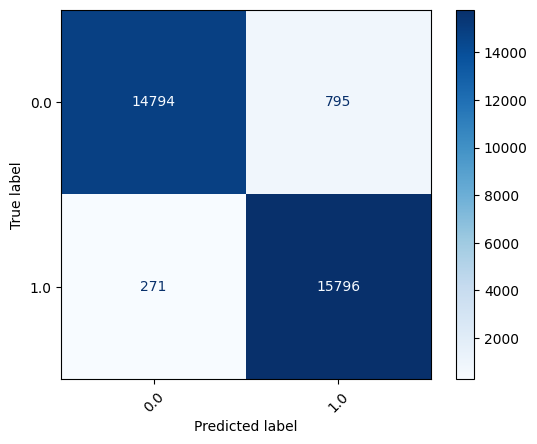

4293

In [12]:
scale_pos_weight = (y1_train == 0).sum() / (y1_train == 1).sum()

xg = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # 🔥 FIX
    random_state=42,
    eval_metric='logloss'
)
xg.fit(x1_train, y1_train)
y_prob = xg.predict_proba(x1_test)[:,1]

threshold = 0.35
xg_pred = (y_prob > threshold).astype(int)
print(xg_pred,y1_test)

print("\n test accuracy = ",accuracy_score(y1_test,xg_pred))
print("Report:\n", classification_report(y1_test, xg_pred))
c6 = confusion_matrix(y1_test,xg_pred)
print("confusion matrix:\n",c6)
unique_labels = sorted(list(set(y1_test).union(set(xg_pred))))
cm_display = ConfusionMatrixDisplay(confusion_matrix=c6,display_labels=unique_labels)
cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

DEEP LEARNING MODEL OF ANN

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
scaler = StandardScaler()

x1_trains = scaler.fit_transform(x1_train)
x1_tests = scaler.transform(x1_test)

model = Sequential([
    Dense(128, activation='relu', input_dim=x1_train.shape[1]),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])
optimizer = Adam(learning_rate=0.0007)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)


history = model.fit(
    x1_trains, y1_train,
    epochs=50,
    batch_size=64,
    validation_data=(x1_tests, y1_test),
    callbacks=[early_stop, lr_scheduler]
)
dl_pred = model.predict(x1_tests)
dl_pred = (dl_pred > 0.35).astype(int)

print(dl_pred,y1_test)


Epoch 1/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7988 - loss: 0.4090 - val_accuracy: 0.9588 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 2/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9457 - loss: 0.1962 - val_accuracy: 0.9669 - val_loss: 0.1425 - learning_rate: 0.0010
Epoch 3/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9542 - loss: 0.1752 - val_accuracy: 0.9669 - val_loss: 0.1425 - learning_rate: 0.0010
Epoch 4/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9579 - loss: 0.1664 - val_accuracy: 0.9666 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 5/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9610 - loss: 0.1599 - val_accuracy: 0.9668 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 6/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9618 - loss: 0.1578 - val_accuracy: 0.9669 - val_loss: 0.1381 - learning_rate: 0.0010
Epoch 7/50
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9627 - 

In [15]:
print("Scaler mean:", scaler.mean_)
print("Scaler scale:", scaler.scale_)

Scaler mean: [9.68012383e+00 1.83939617e+02 1.83502614e+02 5.66001706e+00
 7.76281440e+02 1.34531311e+03 1.00000000e+00 3.00000000e+00
 0.00000000e+00]
Scaler scale: [  5.80584547 100.73546093 100.67710465  38.46195572 554.86718019
 492.25219849   1.           1.           1.        ]


In [16]:
print("\nAccuracy:", accuracy_score(y1_test, dl_pred))
print("\nClassification Report:\n", classification_report(y1_test, dl_pred))


Accuracy: 0.9668941117007834

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.95      0.97     15589
         1.0       0.95      0.98      0.97     16067

    accuracy                           0.97     31656
   macro avg       0.97      0.97      0.97     31656
weighted avg       0.97      0.97      0.97     31656



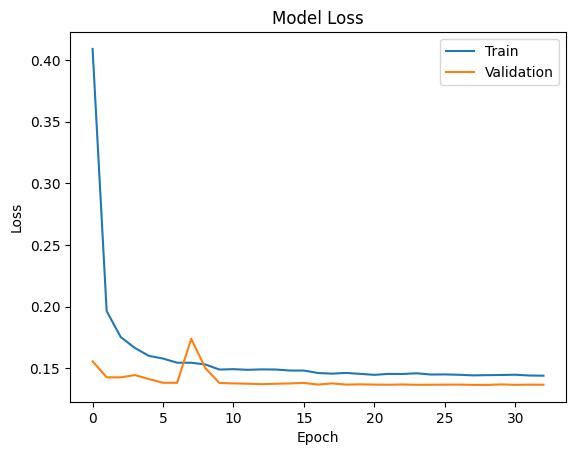

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()


 test accuracy =  0.9668941117007834
Report:
               precision    recall  f1-score   support

         0.0       0.98      0.95      0.97     15589
         1.0       0.95      0.98      0.97     16067

    accuracy                           0.97     31656
   macro avg       0.97      0.97      0.97     31656
weighted avg       0.97      0.97      0.97     31656

confusion matrix:
 [[14820   769]
 [  279 15788]]


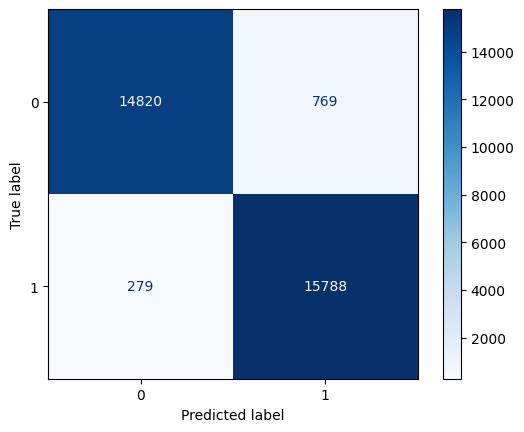

5154

In [18]:
print("\n test accuracy = ",accuracy_score(y1_test,dl_pred))
print("Report:\n", classification_report(y1_test, dl_pred))
c7 = confusion_matrix(y1_test,dl_pred)
print("confusion matrix:\n",c7)
cm_display=ConfusionMatrixDisplay(confusion_matrix=c7).plot(cmap="Blues")
# cm_display.plot(cmap = "Blues",xticks_rotation = 45)
plt.show()
gc.collect()

In [19]:
model.save("deep_learning_cancel.keras")

In [20]:
results = []

def evaluate_model(name, y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    })
evaluate_model("Random Forest", y1_test, rf_pred)
evaluate_model("XGBoost", y1_test, xg_pred)
evaluate_model("Deep Learning", y1_test, dl_pred)
evaluate_model("KNN", y1_test, knn_pred)
evaluate_model("Logistic Regression", y1_test, lr_pred)
evaluate_model("decision tree", y1_test, dt_pred)
evaluate_model("svm", y1_test, svm_pred)

In [21]:
df = pd.DataFrame(results)
print(df.sort_values(by="F1", ascending=False))

                 Model  Accuracy  Precision    Recall        F1
2        Deep Learning  0.966894   0.953554  0.982635  0.967876
1              XGBoost  0.966325   0.952082  0.983133  0.967359
0        Random Forest  0.959218   0.955375  0.964710  0.960020
5        decision tree  0.936284   0.934877  0.939939  0.937401
4  Logistic Regression  0.530895   0.523728  0.835937  0.643987
6                  svm  0.530073   0.524144  0.804631  0.634783
3                  KNN  0.497094   0.503481  0.661605  0.571813


In [22]:
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import joblib
joblib.dump(rf,"random_forest_model_CANCEL.pkl")
joblib.dump(dt,"decision_tree_model_CANCEL.pkl")
joblib.dump(lr,"LogisticRegression_CANCEL.pkl")
joblib.dump(knn,"KNeighborsClassifier_CANCEL.pkl")
joblib.dump(svm,"LinearSVC_CANCEL.pkl")
joblib.dump(xg,"XGBClassifier_CANCEL.pkl")

['XGBClassifier_CANCEL.pkl']

In [38]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os
import warnings

warnings.filterwarnings("ignore")  # optional

tf.get_logger().setLevel('ERROR')

# ==============================
# 🔥 LOAD DL
# ==============================
try:
    from tensorflow.keras.models import load_model
    DL_AVAILABLE = True
except:
    DL_AVAILABLE = False

# ==============================
# 🔥 LOAD FILES
# ==============================
encoders = joblib.load("encoders.pkl")
scaler = joblib.load("scaler_cancel.pkl")

# ==============================
# 🔥 LOAD MODELS
# ==============================
models = {
    "Random Forest": joblib.load("random_forest_model_CANCEL.pkl"),
    "Decision Tree": joblib.load("decision_tree_model_CANCEL.pkl"),
    "Logistic Regression": joblib.load("LogisticRegression_CANCEL.pkl"),
    "SVM": joblib.load("LinearSVC_CANCEL.pkl"),
    "KNN": joblib.load("KNeighborsClassifier_CANCEL.pkl"),
    "XGBoost": joblib.load("XGBClassifier_CANCEL.pkl")
}

# ==============================
# 🔥 SAFE DL LOAD
# ==============================
if DL_AVAILABLE and os.path.exists("deep_learning_cancel.keras"):
    models["Deep Learning"] = load_model("deep_learning_cancel.keras", compile=False)
else:
    print("⚠️ Deep Learning model not found → skipping")

# ==============================
# 🔥 THRESHOLD
# ==============================
THRESHOLD = 0.30

# ==============================
# 🔥 AIRLINE MATCH (ALL 18)
# ==============================
def match_airline_code(le, user_input):
    user_input = user_input.upper().strip()

    code_map = {
        "AA": "AMERICAN",
        "DL": "DELTA",
        "UA": "UNITED",
        "WN": "SOUTHWEST",
        "B6": "JETBLUE",
        "AS": "ALASKA",
        "NK": "SPIRIT",
        "F9": "FRONTIER",
        "G4": "ALLEGIANT",
        "HA": "HAWAIIAN",
        "OO": "SKYWEST",
        "MQ": "ENVOY",
        "EV": "EXPRESSJET",
        "YV": "MESA",
        "VX": "VIRGIN",
        "US": "US AIRWAYS",
        "FL": "AIRTRAN",
        "CO": "CONTINENTAL"
    }

    keyword = code_map.get(user_input, user_input)

    for name in le.classes_:
        if keyword in name.upper():
            return name

    print("⚠️ Airline not found, using default:", le.classes_[0])
    return le.classes_[0]

# ==============================
# 🔥 SAFE ENCODE
# ==============================
def safe_encode(le, value, col):
    value = value.upper()
    if value not in le.classes_:
        print(f"⚠️ Invalid {col}, using default")
        return le.transform([le.classes_[0]])[0]
    return le.transform([value])[0]

# ==============================
# 🔥 INPUT
# ==============================
airline_code = input("\nEnter Airline Code/Name: ")
origin = input("Origin (JFK): ").upper()
dest = input("Destination (LAX): ").upper()

dep_delay = float(input("Departure Delay: "))
distance = float(input("Distance: "))
time = float(input("CRS Time: "))

month = int(input("Month (1-12): "))
day = int(input("Day (1-7): "))
is_weekend = 1 if day in [6,7] else 0

# ==============================
# 🔥 ENCODING
# ==============================
airline_full = match_airline_code(encoders["AIRLINE"], airline_code)

airline_enc = encoders["AIRLINE"].transform([airline_full])[0]
origin_enc = safe_encode(encoders["ORIGIN"], origin, "ORIGIN")
dest_enc = safe_encode(encoders["DEST"], dest, "DEST")

# ==============================
# 🔥 DATAFRAME
# ==============================
cols = [
    'AIRLINE','ORIGIN','DEST',
    'DEP_DELAY','DISTANCE','CRS_DEP_TIME',
    'month','day_of_week','is_weekend'
]

df = pd.DataFrame([[
    airline_enc, origin_enc, dest_enc,
    dep_delay, distance, time,
    month, day, is_weekend
]], columns=cols)

# ==============================
# 🔥 PREDICTION
# ==============================
results = {}

for name, model in models.items():
    temp_df = df.copy()

    try:
        # 🔥 SCALE → KEEP AS DATAFRAME (FIX WARNING)
        if name in ["Logistic Regression","SVM","KNN","Deep Learning"]:
            scaled = pd.DataFrame(
                scaler.transform(temp_df),
                columns=temp_df.columns
            )

        # ======================
        # 🔥 DEEP LEARNING
        # ======================
        if name == "Deep Learning":
            pred_prob = model.predict(np.array(scaled, dtype=np.float32), verbose=0)
            pred = int(pred_prob[0][0] > THRESHOLD)

        # ======================
        # 🔥 SVM
        # ======================
        elif name == "SVM":
            score = model.decision_function(scaled)[0]
            pred = int(score > -0.2)

        # ======================
        # 🔥 KNN
        # ======================
        elif name == "KNN":
            pred = model.predict(scaled)[0]

        # ======================
        # 🔥 XGBOOST
        # ======================
        elif name == "XGBoost":
            prob = float(model.predict_proba(temp_df)[0][1])
            pred = int(prob > THRESHOLD)

        # ======================
        # 🔥 OTHER MODELS
        # ======================
        elif hasattr(model, "predict_proba"):
            prob = model.predict_proba(temp_df)[0][1]
            pred = int(prob > THRESHOLD)

        else:
            pred = model.predict(temp_df)[0]

        results[name] = int(pred)

    except Exception as e:
        results[name] = f"Error: {str(e)}"

# ==============================
# 🔥 OUTPUT
# ==============================
print("\n✈️ CANCELLATION MODEL RESULTS:\n")

for model_name, pred in results.items():
    if pred == 1:
        print(f"{model_name}: ❌ Cancelled")
    elif pred == 0:
        print(f"{model_name}: 🟢 Not Cancelled")
    else:
        print(f"{model_name}: ⚠️ {pred}")

# ==============================
# 🔥 FINAL DECISION
# ==============================
votes = [v for v in results.values() if isinstance(v, int)]

if votes:
    final = round(sum(votes)/len(votes))

    print("\n🎯 FINAL CANCELLATION:")
    print("❌ Cancelled" if final==1 else "🟢 Not Cancelled")


Enter Airline Code/Name: DL
Origin (JFK): CMH
Destination (LAX): ATL
Departure Delay: 0
Distance: 447
CRS Time: 1729
Month (1-12): 1
Day (1-7): 3

✈️ CANCELLATION MODEL RESULTS:

Random Forest: ❌ Cancelled
Decision Tree: ❌ Cancelled
Logistic Regression: ❌ Cancelled
SVM: ❌ Cancelled
KNN: ❌ Cancelled
XGBoost: ❌ Cancelled
Deep Learning: ❌ Cancelled

🎯 FINAL CANCELLATION:
❌ Cancelled
